In [ ]:
      #                Used Car Price Prediction

      #                       Raw Dataset
      #                            │
      #                            ▼
      #                 Business Understanding
      #                            │
      #                            ▼
      #                  Exploratory Data Analysis
      #                (Visualization Only - No Fit)
      #                            │
      #                            ▼
      #             Basic Cleaning (Safe Operations Only)
      #     • Remove duplicates
      #     • Fix column names
      #     • Correct data types
      #     • Remove impossible values
      #                            │
      #                            ▼
      #    Feature Engineering (Row-wise only, no target information)
      #     • Car_Age
      #     • KM_Per_Year
      #     • Luxury_Flag
      #     • Power_per_CC
      #                            │
      #                            ▼
      #          Separate Features (X) and Target (y)
      #                            │
      #                            ▼
      #                Train-Test Split (VERY IMPORTANT)
      #                            │
      #             ┌──────────────┴──────────────┐
      #             ▼                             ▼
      #        X_train                       X_test
      #        y_train                       y_test
      #             │
      #             ▼
      # Detect Numeric & Categorical Columns
      #             │
      #             ▼
      #   ┌───────────────────────────────────────────┐
      #   │           ColumnTransformer               │
      #   │                                           │
      #   │ Numeric Pipeline                          │
      #   │   Median Imputer                          │
      #   │   StandardScaler                          │
      #   │                                           │
      #   │ Categorical Pipeline                      │
      #   │   Most Frequent Imputer                   │
      #   │   OneHotEncoder(handle_unknown="ignore")  │
      #   └───────────────────────────────────────────┘
      #                     │
      #                     ▼
      #                Linear Regression
      #                     │
      #                     ▼
      #               Machine Learning Pipeline
      #                     │
      #                     ▼
      #            model.fit(X_train, y_train)
      #                     │
      #                     ▼
      #           model.predict(X_test)
      #                     │
      #                     ▼
      #                Evaluate Model
      #           R² Score
      #           MAE
      #           RMSE

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

In [ ]:
df = pd.read_csv("/content/cardekho_dataset.csv")

In [ ]:
print(df.head())

print(df.shape)

print(df.info())

   Unnamed: 0       car_name    brand     model  vehicle_age  km_driven  \
0           0    Maruti Alto   Maruti      Alto            9     120000   
1           1  Hyundai Grand  Hyundai     Grand            5      20000   
2           2    Hyundai i20  Hyundai       i20           11      60000   
3           3    Maruti Alto   Maruti      Alto            9      37000   
4           4  Ford Ecosport     Ford  Ecosport            6      30000   

  seller_type fuel_type transmission_type  mileage  engine  max_power  seats  \
0  Individual    Petrol            Manual    19.70     796      46.30      5   
1  Individual    Petrol            Manual    18.90    1197      82.00      5   
2  Individual    Petrol            Manual    17.00    1197      80.00      5   
3  Individual    Petrol            Manual    20.92     998      67.10      5   
4      Dealer    Diesel            Manual    22.77    1498      98.59      5   

   selling_price  
0         120000  
1         550000  
2         2

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


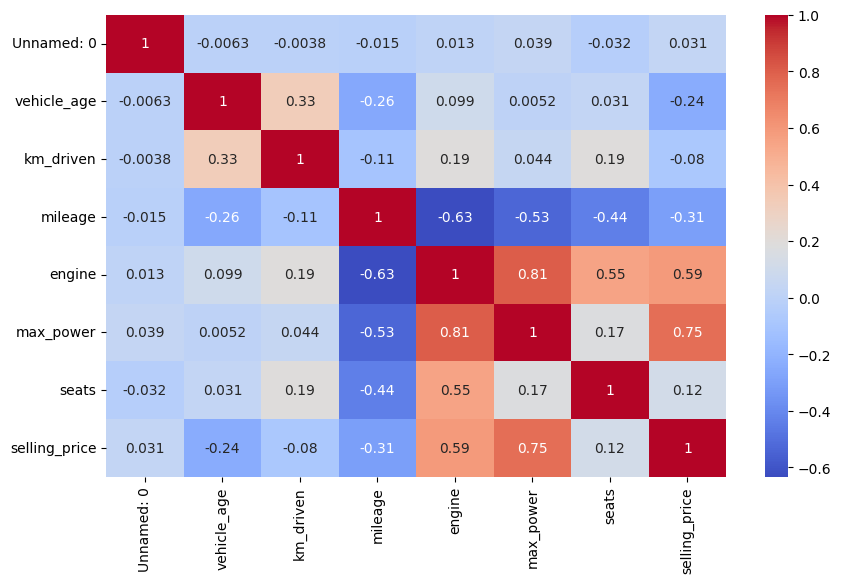

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

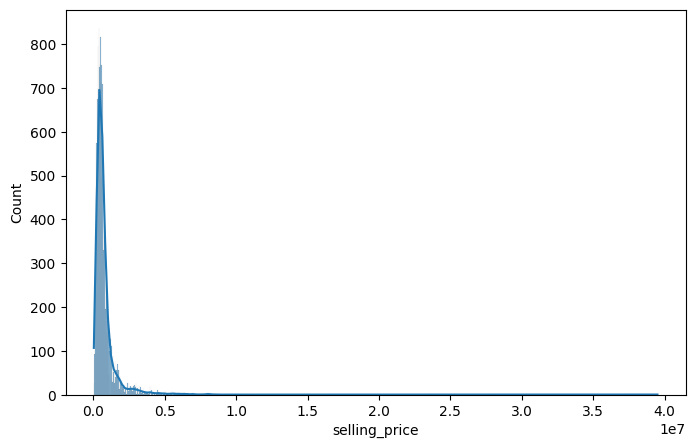

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["selling_price"],
    kde=True
)

plt.show()

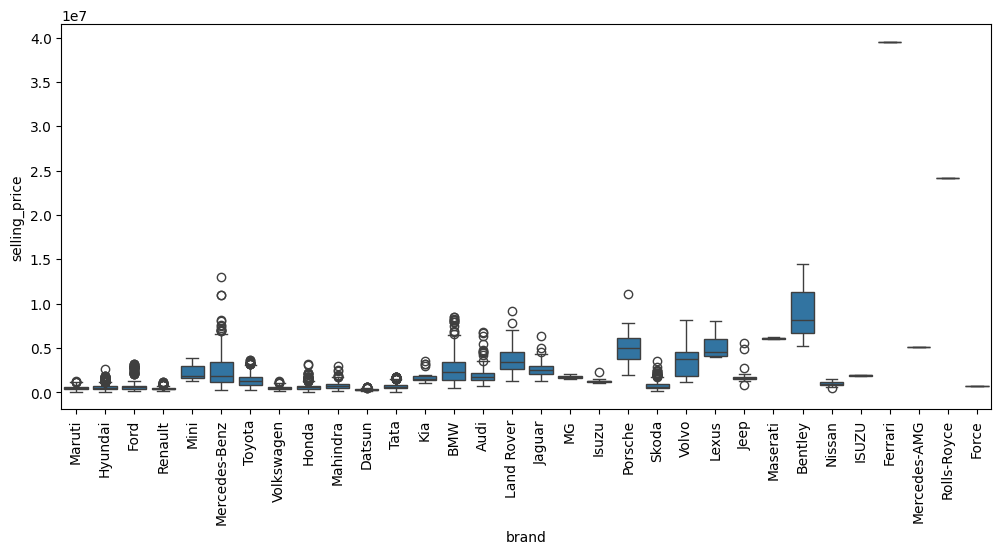

In [ ]:
plt.figure(figsize=(12,5))

sns.boxplot(
    x="brand",
    y="selling_price",
    data=df
)

plt.xticks(rotation=90)

plt.show()

In [ ]:
df.drop(columns="Unnamed: 0", inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.columns = df.columns.str.strip().str.lower()

In [ ]:
df = df[df["selling_price"] > 0]

df = df[df["km_driven"] >= 0]

df = df[df["vehicle_age"] >= 0]

In [ ]:
df["km_per_year"] = (
    df["km_driven"] /
    (df["vehicle_age"] + 1)
)

In [ ]:
df["power_per_cc"] = (
    df["max_power"] /
    df["engine"]
)

In [ ]:
luxury = [
    "BMW",
    "Mercedes-Benz",
    "Audi",
    "Jaguar",
    "Volvo",
    "Lexus",
    "Land Rover"
]

df["luxury_flag"] = (
    df["brand"]
    .isin(luxury)
    .astype(int)
)

In [ ]:
X = df.drop(columns="selling_price")

y = df["selling_price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

In [ ]:
numeric_columns = X_train.select_dtypes(
    include=["int64","float64"]
).columns

In [ ]:
categorical_columns = X_train.select_dtypes(
    include="object"
).columns

In [ ]:
numeric_pipeline = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]

)

In [ ]:
categorical_pipeline = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )

    ]

)

In [ ]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",

            numeric_pipeline,

            numeric_columns
        ),

        (
            "categorical",

            categorical_pipeline,

            categorical_columns
        )

    ]

)

In [ ]:
model = Pipeline(

    steps=[

        (
            "preprocessor",

            preprocessor
        ),

        (
            "linear_regression",

            LinearRegression()
        )

    ]

)

In [ ]:
model.named_steps

{'preprocessor': ColumnTransformer(transformers=[('numeric',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
        'km_per_year', 'power_per_cc', 'luxury_flag'],
       dtype='object')),
                                 ('categorical',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('encoder',
                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                  Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
        'transmission_type'],
       dtype='object'))]),
 

In [ ]:
model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
       'km_per_year', 'power_per_cc', 'luxury_flag'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
       'transmission_type'],
      dtype='object'))])),
                ('linear_regression', LinearRegression())])

In [ ]:
X_test_processed = model.named_steps[
    "preprocessor"
].transform(X_test)

print(X_test_processed.shape)

(3049, 289)


In [ ]:
X_train_processed = model.named_steps[
    "preprocessor"
].transform(X_train)

print(X_train_processed.shape)

(12195, 289)


In [ ]:
train_prediction = model.predict(X_train)

test_prediction = model.predict(X_test)

In [ ]:
train_prediction = model.predict(X_train)

test_prediction = model.predict(X_test)

In [ ]:
print("Train R² :", r2_score(y_train, train_prediction))

print("Test R² :", r2_score(y_test, test_prediction))

print("MAE :", mean_absolute_error(y_test, test_prediction))

print("RMSE :", root_mean_squared_error(y_test, test_prediction))

Train R² : 0.8510005347906402
Test R² : 0.8035212867188581
MAE : 167289.7741822491
RMSE : 345634.4152875943
